<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter3/pendulum_wrapping_around_peg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exact wrapping time vs upper and lower bound times.

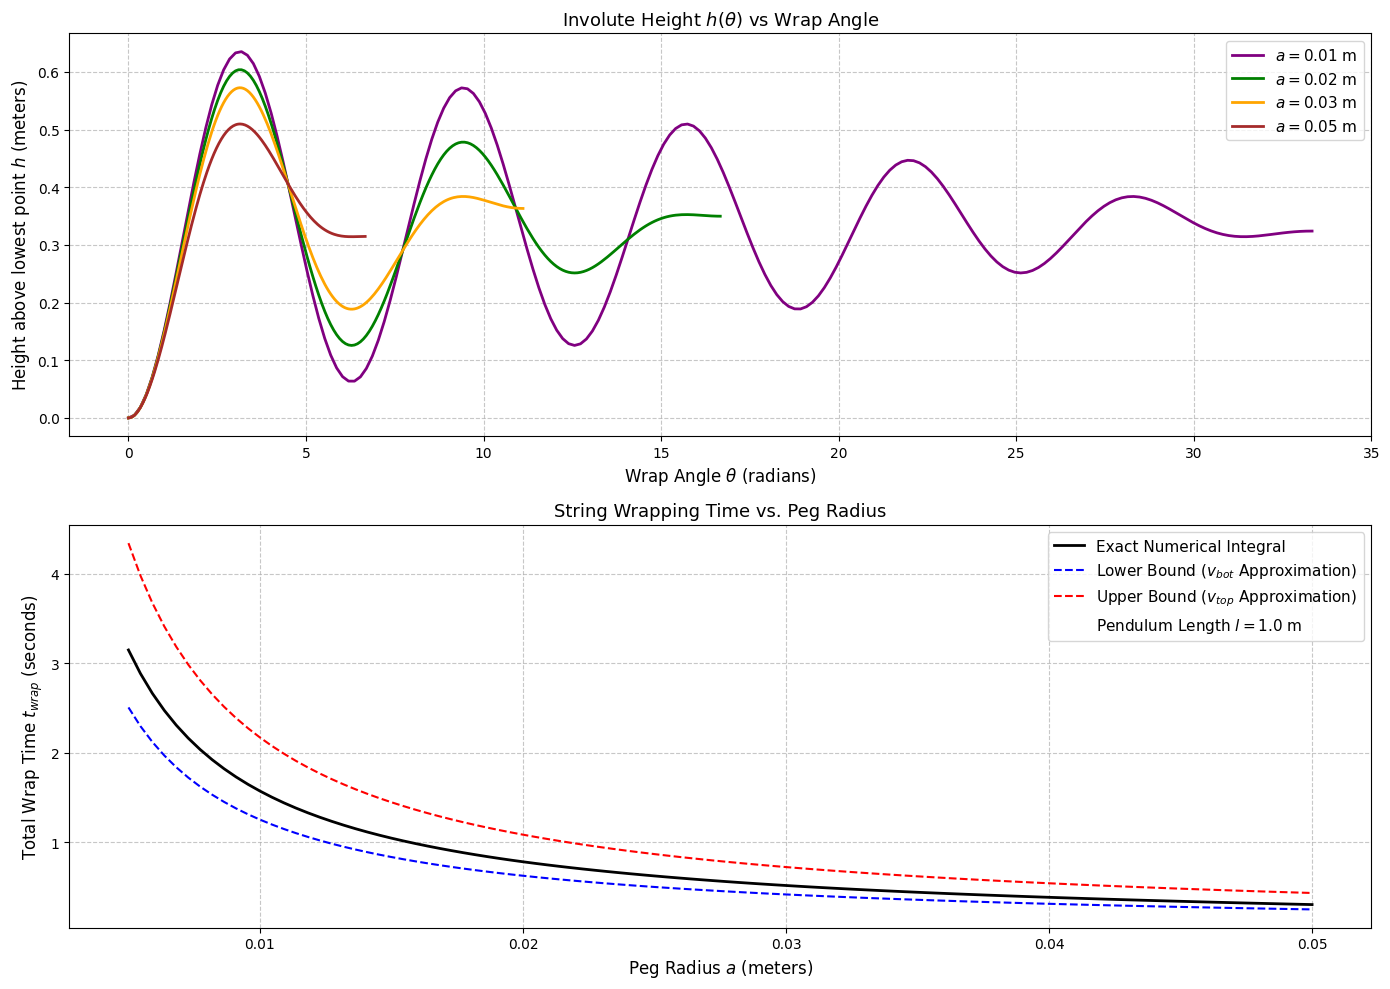

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- System Constants ---
L = 1.0           # Length of the original pendulum (meters)
g = 9.81          # Gravity (m/s^2)
l0 = L / 3.0      # Initial free string length when hitting the peg

# --- 1. The Exact Height and Velocity Equations ---
def h_exact(theta, a):
    # Involute Height h(theta)
    return l0 - a * np.sin(theta) - (l0 - a * theta) * np.cos(theta)

def v_exact(theta, a):
    # Derived from Conservation of Energy using the Involute Height
    return np.sqrt(2 * g * (2*L/3 + a*np.sin(theta) + (l0 - a*theta)*np.cos(theta)))

# --- 2. The Integrand (dt = dl / v) ---
def integrand(theta, a):
    # Free string length divided by exact current velocity
    return (l0 - a * theta) / v_exact(theta, a)

# --- 3. Compute Data across different Peg Radii ---
# Test peg radii from very thin (L/200) to thick (L/20)
a_vals = np.linspace(0.005, 0.05, 100)

t_exact = []
for a in a_vals:
    theta_max = l0 / a  # The angle where the string length becomes 0
    # Numerically integrate the exact equation from 0 to theta_max
    # Pass 'a' as an extra argument to the integrand function using args=(a,)
    res, error = quad(integrand, 0, theta_max, args=(a,))
    t_exact.append(res)

t_exact = np.array(t_exact)

# --- 4. Compute Approximations (From e) ---
# Lower Bound (Assumes fastest constant speed: v_bottom)
t_bot = (l0**2) / (2 * a_vals * np.sqrt(2 * g * L))

# Upper Bound (Assumes slowest constant speed: v_top)
t_top = (l0**2) / (2 * a_vals * np.sqrt(2 * g * (L/3)))

# --- 5 & 6. Plotting ---
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Involute Height vs Angle for multiple peg radii
a_samples = [0.01, 0.02, 0.03, 0.05]
colors = ['purple', 'green', 'orange', 'brown']

for a_samp, color in zip(a_samples, colors):
    theta_max_samp = l0 / a_samp
    theta_vals = np.linspace(0, theta_max_samp, 200)
    h_vals = h_exact(theta_vals, a_samp)
    ax1.plot(theta_vals, h_vals, color=color, linewidth=2.0, label=f'$a = {a_samp}$ m')

ax1.set_title('Involute Height $h(\\theta)$ vs Wrap Angle', fontsize=13)
ax1.set_xlabel('Wrap Angle $\\theta$ (radians)', fontsize=12)
ax1.set_ylabel('Height above lowest point $h$ (meters)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=11, loc='upper right')

# Subplot 2: String Wrapping Time
ax2.plot(a_vals, t_exact, label='Exact Numerical Integral', color='black', linewidth=2)
ax2.plot(a_vals, t_bot, label='Lower Bound ($v_{bot}$ Approximation)', color='blue', linestyle='dashed')
ax2.plot(a_vals, t_top, label='Upper Bound ($v_{top}$ Approximation)', color='red', linestyle='dashed')

# Add an empty line to include the pendulum length L in the legend
ax2.plot([], [], ' ', label=f'Pendulum Length $l = {L}$ m')

ax2.set_title('String Wrapping Time vs. Peg Radius', fontsize=13)
ax2.set_xlabel('Peg Radius $a$ (meters)', fontsize=12)
ax2.set_ylabel('Total Wrap Time $t_{wrap}$ (seconds)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Display the plot
plt.show()
